In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import opentnsim.fis as fis
import xarray as xr
import networkx as nx
from shapely.geometry import Point
import geopandas as gpd
from opentnsim.environment.utils import (create_default_hydrodynamic_dataset, 
                                         add_specific_environmental_data_on_node, 
                                         interpolate_data_on_route,
                                         add_closest_node_to_xr_dataset)
from opentnsim.graph.utils import get_closest_node_to_geometry
%matplotlib inline

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
path = os.getcwd()

In [4]:
df = pd.read_csv(os.path.join(path,"rotterdam_data.csv"), delimiter=';', encoding='ISO-8859-1', on_bad_lines='skip')

In [5]:
df['TIME'] = df['WAARNEMINGDATUM'] + ' ' + df['WAARNEMINGTIJD (MET/CET)']
df['TIME'] = pd.to_datetime(df['TIME'], format = "%d-%m-%Y %H:%M:%S")
df['X'] = df['X'].apply(lambda x: x.replace(",", "."))
df['Y'] = df['Y'].apply(lambda x: x.replace(",", "."))
df = df[['TIME','MEETPUNT_IDENTIFICATIE','NUMERIEKEWAARDE','X','Y','EPSG']]
df = df.rename(columns={'MEETPUNT_IDENTIFICATIE':'Location','NUMERIEKEWAARDE':'Water level'})
df = df.set_index('TIME')

In [6]:
# data_per_location = {}
# for location, df_location in df.groupby('Location'):
#     data_per_location[location] = df_location

In [7]:
# coords_wgs84_per_location = {}
# for location, df_location in data_per_location.items():
#     gdf_location = gpd.GeoDataFrame(df_location, geometry=gpd.points_from_xy(df_location['X'], df_location['Y']), crs=df_location.EPSG.mode().iloc[0])
#     gdf_location = gdf_location.to_crs('EPSG:4326')
#     info = gdf_location.iloc[0]
#     coords_wgs84_per_location[location] = info.geometry

In [8]:
# FG = fis.load_network(version="0.3")

In [9]:
# node_per_location = {}
# for location, geometry in coords_wgs84_per_location.items():
#     node_per_location[location] = get_closest_node_to_geometry(FG, geometry)

In [10]:
# botlek_data = df[df['Location'] == 'Geulhaven Radarpost 10']
# HvH_data = df[df['Location'] == 'Hoek van Holland']
# botlek_data = botlek_data.drop(columns=['Location','X','Y','EPSG'])
# HvH_data = HvH_data.drop(columns=['Location','X','Y','EPSG']);

In [11]:
df_sel = df[df['Location'].isin(['Hoek van Holland','Geulhaven Radarpost 10',])]

In [12]:
df_sel['Water level'] = df_sel['Water level']/100

In [13]:
df_sel.loc[df_sel[df_sel['Water level'] > 100].index,'Water level'] = np.nan
df_sel['Water level'] = df_sel['Water level'].interpolate()

In [14]:
df_sel = df_sel.copy()
df_sel.loc[df_sel['Location'] == 'Geulhaven Radarpost 10', 'Location'] = 'Geulhaven'

In [15]:
df_sel

,Location,Water level,X,Y,EPSG
TIME,,,,,
2026-01-01 00:00:00,Geulhaven,1.20,590321.143000125,5749819.65457646,25831
2026-01-01 00:10:00,Geulhaven,1.24,590321.143000125,5749819.65457646,25831
2026-01-01 00:20:00,Geulhaven,1.27,590321.143000125,5749819.65457646,25831
2026-01-01 00:30:00,Geulhaven,1.31,590321.143000125,5749819.65457646,25831
2026-01-01 00:40:00,Geulhaven,1.36,590321.143000125,5749819.65457646,25831
...,...,...,...,...,...
2026-02-01 23:20:00,Hoek van Holland,-0.72,576915.123,5759061.006,25831
2026-02-01 23:30:00,Hoek van Holland,-0.71,576915.123,5759061.006,25831
2026-02-01 23:40:00,Hoek van Holland,-0.69,576915.123,5759061.006,25831


In [16]:
stations = []
xs = []
ys = []
epsgs = []
wlev_data = []
for station, df_location in df_sel.groupby('Location'):
    x = df_location['X'].mode().iloc[0]
    y = df_location['Y'].mode().iloc[0]
    epsg = df_location['EPSG'].mode().iloc[0]
    time = df_location.index
    stations.append(station)
    xs.append(x)
    ys.append(y)
    epsgs.append(epsg)
    wlev_data.append(df_location['Water level'].values)
wlev_data = np.array(wlev_data)

In [17]:
wlev_xr_da = xr.DataArray(wlev_data, 
                          dims = ('STATION','TIME'), 
                          coords={'STATION':stations,
                                  'TIME':time,
                                  'X': ("STATION", xs),
                                  'Y': ("STATION", ys),
                                  'EPSG': ("STATION", epsgs)})

In [18]:
wlev_xr_da

<xarray.DataArray (STATION: 2, TIME: 4609)> Size: 74kB
array([[ 1.2 ,  1.24,  1.27, ..., -0.6 , -0.6 , -0.59],
       [ 1.4 ,  1.38,  1.35, ..., -0.69, -0.65, -0.61]], shape=(2, 4609))
Coordinates:
  * STATION  (STATION) <U16 128B 'Geulhaven' 'Hoek van Holland'
  * TIME     (TIME) datetime64[ns] 37kB 2026-01-01 ... 2026-02-02
    X        (STATION) <U16 128B '590321.143000125' '576915.123'
    Y        (STATION) <U16 128B '5749819.65457646' '5759061.006'
    EPSG     (STATION) int64 16B 25831 25831

In [19]:
hydrodynamic_data = xr.Dataset()
hydrodynamic_data['Water level'] = wlev_xr_da

In [20]:
hydrodynamic_data.to_netcdf('wlev_measurement_data.nc')

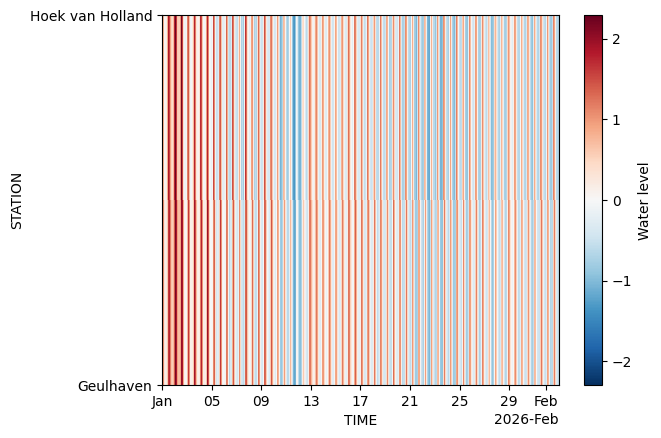

In [21]:
hydrodynamic_data['Water level'].plot()

In [22]:
hydrodynamic_data

<xarray.Dataset> Size: 111kB
Dimensions:      (STATION: 2, TIME: 4609)
Coordinates:
  * STATION      (STATION) <U16 128B 'Geulhaven' 'Hoek van Holland'
  * TIME         (TIME) datetime64[ns] 37kB 2026-01-01 ... 2026-02-02
    X            (STATION) <U16 128B '590321.143000125' '576915.123'
    Y            (STATION) <U16 128B '5749819.65457646' '5759061.006'
    EPSG         (STATION) int64 16B 25831 25831
Data variables:
    Water level  (STATION, TIME) float64 74kB 1.2 1.24 1.27 ... -0.65 -0.61

In [ ]:
break

In [ ]:
hydrodynamic_data = interpolate_data_on_route(hydrodynamic_data, nx.dijkstra_path(env.graph, "8864266", "8866999"), env.graph)

In [ ]:
fig,ax = plt.subplots()
for index,node in enumerate(nx.dijkstra_path(env.graph, "8864266", "8866999")):
    data = hydrodynamic_data.sel({'STATION':node})["Water level"] - hydrodynamic_data.sel({'STATION':node})["Nautical depth"]
    data.plot(ax=ax)
ax.set_xlim([pd.Timestamp('2026-01-01'),pd.Timestamp('2026-01-02')])